In [1]:
import pandas as pd

splits = {'validation': 'data/validation-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}

In [2]:
train_texts = pd.read_parquet("hf://datasets/jhu-clsp/jfleg/" + splits["validation"])
test_texts = pd.read_parquet("hf://datasets/jhu-clsp/jfleg/" + splits["test"])

c:\Users\dinhh\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train_texts

,sentence,corrections
0,So I think we can not live if old people could...,[So I think we would not be alive if our ances...
1,For not use car .,"[Not for use with a car . , Do not use in the ..."
2,Here was no promise of morning except that we ...,"[Here was no promise of morning , except that ..."
3,Thus even today sex is considered as the least...,"[Thus , even today , sex is considered as the ..."
4,image you salf you are wark in factory just to...,[Imagine yourself you are working in factory j...
...,...,...
750,The government also should try to reduce the s...,[The government should also try to reduce the ...
751,Alot of memories with enogh time to remember w...,"[A lot of memories , with enough time to remem..."
752,Sceene of violence can affect on them .,[A scene of violence can have an effect on the...
753,While the communities in general have reckoned...,[The communities in general have reckoned that...


In [4]:
# Hiển thị thông tin cơ bản của dataset
print("Train set info:")
print(train_texts.info())
print("\nSample from train set:")
print(train_texts.head())

Train set info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 755 entries, 0 to 754
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sentence     755 non-null    object
 1   corrections  755 non-null    object
dtypes: object(2)
memory usage: 11.9+ KB
None

Sample from train set:
                                            sentence  \
0  So I think we can not live if old people could...   
1                                 For not use car .    
2  Here was no promise of morning except that we ...   
3  Thus even today sex is considered as the least...   
4  image you salf you are wark in factory just to...   

                                         corrections  
0  [So I think we would not be alive if our ances...  
1  [Not for use with a car . , Do not use in the ...  
2  [Here was no promise of morning , except that ...  
3  [Thus , even today , sex is considered as the ...  
4  [Imagine yourself you are worki

In [5]:
# Kiểm tra cấu trúc của cột corrections
sample_row = train_texts.iloc[0]
print("Original sentence:", sample_row['sentence'])
print("\nType of corrections:", type(sample_row['corrections']))
print("Corrections:")
for i, correction in enumerate(sample_row['corrections']):
    print(f"Correction {i}:", correction)

Original sentence: So I think we can not live if old people could not find siences and tecnologies and they did not developped . 

Type of corrections: <class 'numpy.ndarray'>
Corrections:
Correction 0: So I think we would not be alive if our ancestors did not develop sciences and technologies . 
Correction 1: So I think we could not live if older people did not develop science and technologies . 
Correction 2: So I think we can not live if old people could not find science and technologies and they did not develop . 
Correction 3: So I think we can not live if old people can not find the science and technology that has not been developed . 


In [6]:
# Import necessary library
from difflib import SequenceMatcher
import numpy as np

# Tính độ tương đồng giữa các corrections
def similarity_ratio(str1, str2):
    return SequenceMatcher(None, str1, str2).ratio()

def analyze_corrections_similarity(row):
    corrections = row['corrections']
    similarities = []
    for i in range(len(corrections)):
        for j in range(i+1, len(corrections)):
            sim = similarity_ratio(corrections[i], corrections[j])
            similarities.append(sim)
    return np.mean(similarities)

# Tính độ tương đồng trung bình cho 5 câu đầu tiên
for idx, row in train_texts.head().iterrows():
    print(f"\nSentence {idx}:")
    print("Original:", row['sentence'])
    print(f"Average similarity between corrections: {analyze_corrections_similarity(row):.2f}")


Sentence 0:
Original: So I think we can not live if old people could not find siences and tecnologies and they did not developped . 
Average similarity between corrections: 0.73

Sentence 1:
Original: For not use car . 
Average similarity between corrections: 0.66

Sentence 2:
Original: Here was no promise of morning except that we looked up through the trees we saw how low the forest had swung . 
Average similarity between corrections: 0.95

Sentence 3:
Original: Thus even today sex is considered as the least important topic in many parts of India . 
Average similarity between corrections: 0.98

Sentence 4:
Original: image you salf you are wark in factory just to do one thing like pot taire on car if they fire you you will destroy , becouse u dont know more than pot taire in car . 
Average similarity between corrections: 0.62


In [7]:
import random

def get_correction_methods(row):
    corrections = row['corrections']
    
    # Method 1: Random selection
    random_correction = random.choice(corrections)
    
    # Method 2: Voting (if there are duplicates)
    from collections import Counter
    correction_counts = Counter(corrections)
    most_common = correction_counts.most_common(1)[0][0]
    
    # Method 3: Similarity-based selection
    avg_similarities = []
    for i, corr1 in enumerate(corrections):
        total_sim = sum(similarity_ratio(corr1, corr2) for j, corr2 in enumerate(corrections) if i != j)
        avg_sim = total_sim / (len(corrections) - 1)
        avg_similarities.append((avg_sim, corr1))
    most_similar = max(avg_similarities, key=lambda x: x[0])[1]
    
    return {
        'random': random_correction,
        'voting': most_common,
        'similarity': most_similar
    }

In [8]:
# Áp dụng random selection cho toàn bộ dataset
def apply_random_correction(df):
    # Tạo copy của DataFrame để không ảnh hưởng đến dữ liệu gốc
    result_df = pd.DataFrame()
    result_df['original'] = df['sentence']
    result_df['corrected'] = df['corrections'].apply(lambda x: random.choice(x))
    return result_df

# Áp dụng cho training và test set
train_processed = apply_random_correction(train_texts)
test_processed = apply_random_correction(test_texts)

# Hiển thị một số ví dụ
print("Sample results from training set:")
for idx, row in train_processed.head().iterrows():
    print("\nPair", idx + 1)
    print("Original:", row['original'])
    print("Corrected:", row['corrected'])

Sample results from training set:

Pair 1
Original: So I think we can not live if old people could not find siences and tecnologies and they did not developped . 
Corrected: So I think we can not live if old people can not find the science and technology that has not been developed . 

Pair 2
Original: For not use car . 
Corrected: Do not use in the car . 

Pair 3
Original: Here was no promise of morning except that we looked up through the trees we saw how low the forest had swung . 
Corrected: There was no promise of morning except when we looked up through the trees and saw how low the forest had swung . 

Pair 4
Original: Thus even today sex is considered as the least important topic in many parts of India . 
Corrected: Thus , even today , sex is considered as the least important topic in may parts of India . 

Pair 5
Original: image you salf you are wark in factory just to do one thing like pot taire on car if they fire you you will destroy , becouse u dont know more than pot tair

In [9]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.util import ngrams
import re
from collections import defaultdict

# Download tất cả các gói NLTK cần thiết
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('treebank')
nltk.download('maxent_treebank_pos_tagger')
nltk.download('tagsets')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dinhh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\dinhh\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\dinhh\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\dinhh\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package treebank to
[nltk_data]     C:\Users\dinhh\AppData\Roaming\nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package maxent_treebank_pos_tagger to
[nltk_data]     C:\Users\dinhh\AppData\Roaming\nltk_data...
[nltk_data]   Package maxen

True

In [10]:
# Hàm tiền xử lý cơ bản
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Chuẩn hóa dấu câu
    text = re.sub(r'[^\w\s.,!?]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # POS tagging
    pos_tags = pos_tag(tokens)
    # N-grams (2-gram và 3-gram)
    bigrams = list(ngrams(tokens, 2))
    trigrams = list(ngrams(tokens, 3))
    
    return {
        'tokens': tokens,
        'pos_tags': pos_tags,
        'bigrams': bigrams,
        'trigrams': trigrams
    }

# Áp dụng cho một vài ví dụ
for idx, row in train_processed.head(2).iterrows():
    print(f"\nExample {idx + 1}:")
    print("Original:", row['original'])
    print("Corrected:", row['corrected'])
    
    orig_features = preprocess_text(row['original'])
    corr_features = preprocess_text(row['corrected'])
    
    print("\nFeatures comparison:")
    print("Original POS tags:", orig_features['pos_tags'])
    print("Corrected POS tags:", corr_features['pos_tags'])


Example 1:
Original: So I think we can not live if old people could not find siences and tecnologies and they did not developped . 
Corrected: So I think we can not live if old people can not find the science and technology that has not been developed . 

Features comparison:
Original POS tags: [('so', 'RB'), ('i', 'JJ'), ('think', 'VBP'), ('we', 'PRP'), ('can', 'MD'), ('not', 'RB'), ('live', 'VB'), ('if', 'IN'), ('old', 'JJ'), ('people', 'NNS'), ('could', 'MD'), ('not', 'RB'), ('find', 'VB'), ('siences', 'NNS'), ('and', 'CC'), ('tecnologies', 'NNS'), ('and', 'CC'), ('they', 'PRP'), ('did', 'VBD'), ('not', 'RB'), ('developped', 'VBN'), ('.', '.')]
Corrected POS tags: [('so', 'RB'), ('i', 'JJ'), ('think', 'VBP'), ('we', 'PRP'), ('can', 'MD'), ('not', 'RB'), ('live', 'VB'), ('if', 'IN'), ('old', 'JJ'), ('people', 'NNS'), ('can', 'MD'), ('not', 'RB'), ('find', 'VB'), ('the', 'DT'), ('science', 'NN'), ('and', 'CC'), ('technology', 'NN'), ('that', 'WDT'), ('has', 'VBZ'), ('not', 'RB'), ('b

In [11]:
# Import thư viện cho spell checking
from spellchecker import SpellChecker
from Levenshtein import distance

# Tạo spell checker
spell = SpellChecker()

In [12]:
# Tất cả các hàm phát hiện lỗi
def detect_spelling_errors(tokens):
    misspelled = []
    for i, token in enumerate(tokens):
        # Bỏ qua các từ viết hoa và từ ngắn
        if token.isupper() or len(token) < 2:
            continue
        # Kiểm tra lỗi chính tả
        if token.lower() not in spell:
            try:
                candidates = list(spell.candidates(token))
            except:
                candidates = []  # Nếu không tìm được suggestions thì để rỗng
            misspelled.append({
                'position': i,
                'word': token,
                'suggestions': candidates if candidates else []
            })
    return misspelled

def detect_article_errors(pos_tags):
    article_errors = []
    for i in range(len(pos_tags)-1):
        word, tag = pos_tags[i]
        next_word, next_tag = pos_tags[i+1]
        
        if word.lower() in ['a', 'an']:
            if next_tag.startswith('NN'):
                should_be_an = next_word[0].lower() in 'aeiou'
                if (word.lower() == 'a' and should_be_an) or (word.lower() == 'an' and not should_be_an):
                    article_errors.append((i, word, 'an' if should_be_an else 'a'))
    return article_errors

# Danh sách prepositions phổ biến
COMMON_PREPOSITIONS = {
    'in': ['at', 'on', 'by'],
    'on': ['in', 'at', 'by'],
    'at': ['in', 'on', 'by'],
    'to': ['for', 'into', 'toward'],
    'for': ['to', 'of', 'with'],
    'with': ['by', 'in', 'through'],
    'of': ['from', 'about', 'with'],
    'by': ['with', 'through', 'from']
}

def detect_preposition_errors(pos_tags):
    preposition_errors = []
    for i, (word, tag) in enumerate(pos_tags):
        if tag == 'IN' and word.lower() in COMMON_PREPOSITIONS:
            preposition_errors.append({
                'position': i,
                'word': word,
                'suggestions': COMMON_PREPOSITIONS[word.lower()]
            })
    return preposition_errors

def detect_subject_verb_agreement(pos_tags):
    agreement_errors = []
    subject_verb_pairs = [
        # I/you/we/they + base form
        (['PRP'], ['VBZ']),  
        # he/she/it + 3rd person
        (['PRP'], ['VBP']), 
        # Singular noun + base form
        (['NN'], ['VBP']),
        # Plural noun + 3rd person
        (['NNS'], ['VBZ'])
    ]
    
    for i in range(len(pos_tags)-1):
        word, tag = pos_tags[i]
        next_word, next_tag = pos_tags[i+1]
        
        # Check common subject-verb agreement patterns
        for subj_tags, verb_tags in subject_verb_pairs:
            if tag in subj_tags and next_tag in verb_tags:
                if word.lower() in ['i', 'you', 'we', 'they'] and next_tag == 'VBZ':
                    agreement_errors.append({
                        'position': i+1,
                        'word': next_word,
                        'type': 'subject-verb agreement',
                        'context': f"{word} {next_word}",
                        'suggestion': 'use base form'
                    })
                elif word.lower() in ['he', 'she', 'it'] and next_tag == 'VBP':
                    agreement_errors.append({
                        'position': i+1,
                        'word': next_word,
                        'type': 'subject-verb agreement',
                        'context': f"{word} {next_word}",
                        'suggestion': 'use third person singular'
                    })
    return agreement_errors

# Danh sách các hàm phát hiện lỗi
def detect_all_errors(tokens, pos_tags):
    return {
        'spelling_errors': detect_spelling_errors(tokens),
        'article_errors': detect_article_errors(pos_tags),
        'preposition_errors': detect_preposition_errors(pos_tags),
        'agreement_errors': detect_subject_verb_agreement(pos_tags)
    }

In [13]:
def analyze_errors(text):
    # Tiền xử lý
    features = preprocess_text(text)
    tokens = features['tokens']
    pos_tags = features['pos_tags']
    
    # Phát hiện lỗi
    spelling_errors = detect_spelling_errors(tokens)
    article_errors = detect_article_errors(pos_tags)
    preposition_errors = detect_preposition_errors(pos_tags)
    agreement_errors = detect_subject_verb_agreement(pos_tags)
    
    return {
        'spelling_errors': spelling_errors,
        'article_errors': article_errors,
        'preposition_errors': preposition_errors,
        'agreement_errors': agreement_errors
    }

# Test với một số câu từ dataset
for idx, row in train_processed.head(3).iterrows():
    print(f"\nAnalyzing sentence {idx + 1}:")
    print("Original:", row['original'])
    print("Corrected:", row['corrected'])
    
    errors = analyze_errors(row['original'])
    
    print("\nDetected errors:")
    for error_type, error_list in errors.items():
        if error_list:
            print(f"\n{error_type.replace('_', ' ').title()}:")
            for error in error_list:
                if isinstance(error, dict):
                    print(f"Word '{error['word']}' at position {error['position']}")
                    if 'suggestion' in error:
                        print(f"  Suggestion: {error['suggestion']}")
                    elif 'suggestions' in error:
                        print(f"  Suggestions: {error['suggestions']}")
                    if 'context' in error:
                        print(f"  Context: {error['context']}")
                else:
                    i, word, suggestion = error
                    print(f"'{word}' should be '{suggestion}' at position {i}")


Analyzing sentence 1:
Original: So I think we can not live if old people could not find siences and tecnologies and they did not developped . 
Corrected: So I think we can not live if old people can not find the science and technology that has not been developed . 

Detected errors:

Spelling Errors:
Word 'siences' at position 13
  Suggestions: ['silences', 'sciences']
Word 'tecnologies' at position 15
  Suggestions: ['technologies']
Word 'developped' at position 20
  Suggestions: ['developed']

Analyzing sentence 2:
Original: For not use car . 
Corrected: Do not use in the car . 

Detected errors:

Preposition Errors:
Word 'for' at position 0
  Suggestions: ['to', 'of', 'with']

Analyzing sentence 3:
Original: Here was no promise of morning except that we looked up through the trees we saw how low the forest had swung . 
Corrected: There was no promise of morning except when we looked up through the trees and saw how low the forest had swung . 

Detected errors:

Preposition Errors:


In [14]:
# Import thư viện cho ML
from sklearn.feature_extraction import DictVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np

def create_feature_vector(text, corrected_text):
    try:
        # Phát hiện lỗi từ cả câu gốc và câu sửa
        orig_errors = analyze_errors(text)
        corr_errors = analyze_errors(corrected_text)
        
        # Tạo features cơ bản
        features = {
            'has_spelling_errors': bool(orig_errors['spelling_errors']),
            'spelling_error_count': len(orig_errors['spelling_errors']),
            'has_article_errors': bool(orig_errors['article_errors']),
            'article_error_count': len(orig_errors['article_errors']),
            'has_preposition_errors': bool(orig_errors['preposition_errors']),
            'preposition_error_count': len(orig_errors['preposition_errors']),
            'has_agreement_errors': bool(orig_errors['agreement_errors']),
            'agreement_error_count': len(orig_errors['agreement_errors']),
            'text_length': len(text.split()),
            'avg_word_length': sum(len(word) for word in text.split()) / len(text.split()) if text else 0
        }

        # Thêm features mới
        text_features = preprocess_text(text)
        pos_tags = text_features['pos_tags']
        
        # Thêm POS sequence features
        pos_sequence = ' '.join([tag for word, tag in pos_tags])
        features['pos_sequence'] = pos_sequence
        
        # Thêm verb agreement features
        verb_tags = ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ']
        features['verb_count'] = sum(1 for _, tag in pos_tags if tag in verb_tags)
        
        # Kiểm tra subject-verb agreement cụ thể
        for i in range(len(pos_tags)-1):
            if pos_tags[i][1] in ['NN', 'NNS'] and pos_tags[i+1][1] in ['VBZ', 'VBP']:
                features['has_potential_agreement_error'] = True
                break
        else:
            features['has_potential_agreement_error'] = False
        
        # So sánh text gốc và text sửa để xác định label
        needs_correction = text.lower().strip() != corrected_text.lower().strip()
        
        return features, needs_correction

    except Exception as e:
        print(f"Error processing text: {text}")
        print(f"Error: {str(e)}")
        return {
            # ...existing code for default features...
            'pos_sequence': '',
            'verb_count': 0,
            'has_potential_agreement_error': False
        }, False

# Test với các câu có lỗi rõ ràng
test_sentences = [
    ("I has a dog", "I have a dog"),
    ("She go to school everyday", "She goes to school everyday"),
    ("This is a correct sentence with proper grammar.", "This is a correct sentence with proper grammar."),
    ("He work in office", "He works in the office"),
    ("I am going to school tomorrow", "I am going to school tomorrow")
]

print("Testing error detection with known corrections:")
for original, corrected in test_sentences:
    features, needs_correction = create_feature_vector(original, corrected)
    print(f"\nAnalyzing: {original}")
    print(f"Correct form: {corrected}")
    print(f"Detected as needing correction: {needs_correction}")
    print("Features found:")
    for key, value in features.items():
        if value:  # Chỉ in các features có giá trị
            print(f"- {key}: {value}")

Testing error detection with known corrections:

Analyzing: I has a dog
Correct form: I have a dog
Detected as needing correction: True
Features found:
- text_length: 4
- avg_word_length: 2.0
- pos_sequence: NN VBZ DT NN
- verb_count: 1
- has_potential_agreement_error: True

Analyzing: She go to school everyday
Correct form: She goes to school everyday
Detected as needing correction: True
Features found:
- has_agreement_errors: True
- agreement_error_count: 1
- text_length: 5
- avg_word_length: 4.2
- pos_sequence: PRP VBP TO NN NN
- verb_count: 1

Analyzing: This is a correct sentence with proper grammar.
Correct form: This is a correct sentence with proper grammar.
Detected as needing correction: False
Features found:
- has_preposition_errors: True
- preposition_error_count: 1
- text_length: 8
- avg_word_length: 5.0
- pos_sequence: DT VBZ DT JJ NN IN JJ NN .
- verb_count: 1

Analyzing: He work in office
Correct form: He works in the office
Detected as needing correction: True
Features

In [15]:
# Import thêm thư viện cho feature engineering và model tuning
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def create_advanced_feature_vector(text, corrected_text):
    try:
        # Phát hiện lỗi từ cả câu gốc và câu sửa
        orig_errors = analyze_errors(text)
        text_features = preprocess_text(text)
        pos_tags = text_features['pos_tags']
        tokens = text_features['tokens']
        
        # Tạo features cơ bản
        features = {
            # Error-based features
            'spelling_error_ratio': len(orig_errors['spelling_errors']) / len(tokens) if tokens else 0,
            'article_error_ratio': len(orig_errors['article_errors']) / len(tokens) if tokens else 0,
            'preposition_error_ratio': len(orig_errors['preposition_errors']) / len(tokens) if tokens else 0,
            'agreement_error_ratio': len(orig_errors['agreement_errors']) / len(tokens) if tokens else 0,
            
            # Structural features
            'sentence_length': len(tokens),
            'avg_word_length': sum(len(word) for word in tokens) / len(tokens) if tokens else 0,
            
            # POS-based features
            'verb_ratio': sum(1 for _, tag in pos_tags if tag.startswith('VB')) / len(pos_tags) if pos_tags else 0,
            'noun_ratio': sum(1 for _, tag in pos_tags if tag.startswith('NN')) / len(pos_tags) if pos_tags else 0,
            'adj_ratio': sum(1 for _, tag in pos_tags if tag.startswith('JJ')) / len(pos_tags) if pos_tags else 0,
            
            # Agreement features
            'has_subject_verb_mismatch': any(
                pos_tags[i][1] in ['NN', 'NNS'] and 
                i + 1 < len(pos_tags) and 
                pos_tags[i+1][1] in ['VBZ', 'VBP']
                for i in range(len(pos_tags) - 1)
            )
        }
        
        # Xác định label bằng cách so sánh nội dung và cấu trúc
        needs_correction = (
            text.lower().strip() != corrected_text.lower().strip() or
            any(len(orig_errors[err_type]) > 0 for err_type in orig_errors)
        )
        
        return features, needs_correction

    except Exception as e:
        print(f"Error processing text: {text}")
        print(f"Error: {str(e)}")
        return {
            'spelling_error_ratio': 0,
            'article_error_ratio': 0,
            'preposition_error_ratio': 0,
            'agreement_error_ratio': 0,
            'sentence_length': 0,
            'avg_word_length': 0,
            'verb_ratio': 0,
            'noun_ratio': 0,
            'adj_ratio': 0,
            'has_subject_verb_mismatch': False
        }, False
    
def prepare_training_data(df, n_samples=1000, feature_function=None):
    features_list = []
    labels = []
    
    # Use default feature function if none provided
    if feature_function is None:
        feature_function = create_feature_vector
    
    print(f"Processing {n_samples} samples...")
    for idx, row in df.head(n_samples).iterrows():
        try:
            features, label = feature_function(row['original'], row['corrected'])
            features_list.append(features)
            labels.append(label)
        except Exception as e:
            print(f"Error processing row {idx}: {str(e)}")
            continue
    
    if not features_list:
        raise ValueError("No valid features were extracted")
    
    print(f"Successfully processed {len(features_list)} samples")
    
    # Convert features to matrix
    vectorizer = DictVectorizer()
    X = vectorizer.fit_transform(features_list)
    y = np.array(labels)
    
    return X, y, vectorizer

In [16]:
from sklearn.utils import resample
from sklearn.metrics import make_scorer, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import scipy.sparse
import numpy as np

def create_model_pipeline():
    clf = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        n_estimators=300,
        max_depth=30
    )
    
    pipeline = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('classifier', clf)
    ])
    
    return pipeline

print("Processing dataset...")
X, y, vectorizer = prepare_training_data(
    train_processed, 
    n_samples=len(train_processed),
    feature_function=create_advanced_feature_vector
)

# Split và train
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
model = create_model_pipeline()
model.fit(X_train, y_train)

# Evaluate trên validation set
val_pred = model.predict(X_val)
print("\nValidation Metrics:")
print(classification_report(y_val, val_pred))

Processing dataset...
Processing 755 samples...
Successfully processed 755 samples

Validation Metrics:
              precision    recall  f1-score   support

       False       0.38      0.38      0.38         8
        True       0.97      0.97      0.97       143

    accuracy                           0.93       151
   macro avg       0.67      0.67      0.67       151
weighted avg       0.93      0.93      0.93       151



In [17]:
def preserve_case(original_word, corrected_word):
    """Giữ nguyên chữ hoa/thường như từ gốc"""
    if not original_word or not corrected_word:
        return corrected_word
    if original_word.isupper():
        return corrected_word.upper()
    if original_word[0].isupper():
        return corrected_word.capitalize()
    return corrected_word.lower()

def auto_correct_sentence(text):
    """Tự động sửa lỗi trong câu dựa trên các loại lỗi đã phát hiện"""
    # Lưu trữ text gốc để giữ nguyên chữ hoa/thường
    original_words = text.split()
    
    # Phát hiện lỗi
    errors = analyze_errors(text)
    features = preprocess_text(text)
    tokens = features['tokens']
    pos_tags = features['pos_tags']
    words = list(tokens)
    
    # Dictionary ánh xạ verb forms
    verb_forms = {
        'has': 'have',    'have': 'has',
        'go': 'goes',     'goes': 'go', 
        'work': 'works',  'works': 'work',
        'do': 'does',     'does': 'do',
        'write': 'writes', 'writes': 'write',
        'make': 'makes',  'makes': 'make'
    }
    
    # 1. Sửa lỗi subject-verb agreement (ưu tiên cao nhất)
    if errors['agreement_errors']:
        for error in errors['agreement_errors']:
            if isinstance(error, dict):
                pos = error['position']
                word = words[pos]
                subject = words[pos-1].lower()
                
                # Xử lý theo subject
                if subject in ['i', 'you', 'we', 'they']:
                    # Chuyển về base form
                    if word in verb_forms and word.endswith('s'):
                        words[pos] = verb_forms[word]
                elif subject in ['he', 'she', 'it']:
                    # Chuyển về third person singular
                    if word in verb_forms and not word.endswith('s'):
                        words[pos] = verb_forms[word]
    
    # 2. Sửa lỗi article
    if errors['article_errors']:
        for error in errors['article_errors']:
            pos, word, correction = error
            words[pos] = correction
    
    # 3. Sửa giới từ và thêm/bỏ article "the"
    if errors['preposition_errors']:
        for error in errors['preposition_errors']:
            if isinstance(error, dict):
                pos = error['position']
                if words[pos] == 'in' and pos == len(words) - 2:  # Trường hợp cuối câu
                    words[pos] = 'at'
                    if 'the' not in [w.lower() for w in words]:
                        words.insert(pos + 1, 'the')
    
    # Khôi phục chữ hoa/thường và thêm các từ mới
    corrected_words = []
    for i, word in enumerate(words):
        if i < len(original_words):
            corrected_words.append(preserve_case(original_words[i], word))
        else:
            corrected_words.append(word)  # Các từ mới được thêm vào
    
    # Ghép lại thành câu
    return ' '.join(corrected_words)

# Test hàm với các ví dụ
test_sentences = [
    "She go to school everyday",
    "He work in office"
]

print("Testing automatic error correction:")
for text in test_sentences:
    errors = analyze_errors(text)
    corrected = auto_correct_sentence(text)
    
    print(f"\nOriginal: {text}")
    print(f"Corrected: {corrected}")
    print("Fixed errors:")
    for error_type, error_list in errors.items():
        if error_list:
            print(f"\n{error_type.replace('_', ' ').title()}:")
            for error in error_list:
                if isinstance(error, dict):
                    print(f"- Changed '{error['word']}' at position {error['position']}")
                    if 'suggestion' in error:
                        print(f"  Applied: {error['suggestion']}")
                else:
                    i, word, suggestion = error
                    print(f"- Changed '{word}' -> '{suggestion}'")

Testing automatic error correction:

Original: She go to school everyday
Corrected: She goes to school everyday
Fixed errors:

Agreement Errors:
- Changed 'go' at position 1
  Applied: use third person singular

Original: He work in office
Corrected: He work at the office
Fixed errors:

Preposition Errors:
- Changed 'in' at position 2


In [18]:
from Levenshtein import distance
from sklearn.metrics import f1_score
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu, corpus_bleu
from nltk.tokenize import word_tokenize

# Tạo smoothing function cho BLEU score
chencherry = SmoothingFunction()

def calculate_bleu_score(candidate, reference, weights=(0.25, 0.25, 0.25, 0.25)):
    """Tính BLEU score cho một cặp câu với smoothing"""
    if isinstance(reference, str):
        reference = [reference]
    
    # Tokenize
    candidate_tokens = word_tokenize(candidate.lower())
    reference_tokens = [word_tokenize(ref.lower()) for ref in reference]
    
    # Tính BLEU score với smoothing
    try:
        return sentence_bleu(reference_tokens, candidate_tokens, 
                           weights=weights,
                           smoothing_function=chencherry.method1)
    except Exception as e:
        print(f"Error calculating BLEU score: {e}")
        return 0.0

def calculate_corpus_bleu(candidates, references, weights=(0.25, 0.25, 0.25, 0.25)):
    """Tính BLEU score cho toàn bộ corpus"""
    # Tokenize tất cả câu
    candidates_tokens = [word_tokenize(c.lower()) for c in candidates]
    references_tokens = [[word_tokenize(r.lower())] for r in references]
    
    try:
        return corpus_bleu(references_tokens, candidates_tokens,
                         weights=weights,
                         smoothing_function=chencherry.method1)
    except Exception as e:
        print(f"Error calculating corpus BLEU: {e}")
        return 0.0

def calculate_metrics(predictions, targets):
    exact_matches = 0
    total_distance = 0
    num_samples = len(predictions)
    
    # Tính các corrections cho F1
    true_corrections = []
    pred_corrections = []
    
    # Tính toán từng cặp câu
    sentence_bleu_scores = []
    for pred, target in zip(predictions, targets):
        # Exact Match
        if pred.strip() == target.strip():
            exact_matches += 1
        
        # Levenshtein Distance
        total_distance += distance(pred, target)
        
        # Corrections cho F1
        true_corrections.append(target != pred)
        pred_corrections.append(any(analyze_errors(pred).values()))
        
        # BLEU score cho từng câu
        bleu = calculate_bleu_score(pred, target)
        sentence_bleu_scores.append(bleu)
    
    # Tính các metrics
    metrics = {
        'exact_match_accuracy': exact_matches / num_samples,
        'correction_f1': f1_score(true_corrections, pred_corrections, average='binary'),
        'avg_levenshtein': total_distance / num_samples,
        'corpus_bleu': calculate_corpus_bleu(predictions, targets),
        'avg_sentence_bleu': sum(sentence_bleu_scores) / len(sentence_bleu_scores)
    }
    
    return metrics

# Chuẩn bị tập test và tính metrics
print("Processing test set...")
test_original = test_texts['sentence'].tolist()
test_corrections = test_texts['corrections'].tolist()
test_targets = [corrections[0] for corrections in test_corrections]

predictions = []
for text in test_original:
    corrected = auto_correct_sentence(text)
    predictions.append(corrected)

# Tính và hiển thị metrics
metrics = calculate_metrics(predictions, test_targets)

print("\nTest Set Metrics:")
print(f"Exact Match Accuracy: {metrics['exact_match_accuracy']:.4f}")
print(f"Correction F1-score: {metrics['correction_f1']:.4f}")
print(f"Average Levenshtein Distance: {metrics['avg_levenshtein']:.4f}")
print(f"Corpus BLEU Score: {metrics['corpus_bleu']:.4f}")
print(f"Average Sentence BLEU Score: {metrics['avg_sentence_bleu']:.4f}")

# In một số ví dụ với BLEU score
print("\nSample predictions:")
for orig, pred, target in list(zip(test_original, predictions, test_targets))[:5]:
    bleu = calculate_bleu_score(pred, target)
    print(f"\nOriginal: {orig}")
    print(f"Predicted: {pred}")
    print(f"Target: {target}")
    print(f"BLEU Score: {bleu:.4f}")
    print(f"Levenshtein Distance: {distance(pred, target)}")

Processing test set...

Test Set Metrics:
Exact Match Accuracy: 0.1270
Correction F1-score: 0.8624
Average Levenshtein Distance: 10.5561
Corpus BLEU Score: 0.6644
Average Sentence BLEU Score: 0.6235

Sample predictions:

Original: New and new technology has been introduced to the society .
Predicted: New and new technology has been introduced to the society .
Target: New technology has been introduced to society .
BLEU Score: 0.5193
Levenshtein Distance: 12

Original: One possible outcome is that an environmentally-induced reduction in motorization levels in the richer countries will outweigh any rise in motorization levels in the poorer countries .
Predicted: One possible outcome is that an environmentallyinduced reduction in motorization levels in the richer countries will outweigh any rise in motorization levels in the poorer countries .
Target: One possible outcome is that an environmentally-induced reduction in motorization levels in richer countries will outweigh any rise in moto

C:\Users\dinhh\AppData\Local\Temp\ipykernel_11016\1152169293.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=feature_importance,


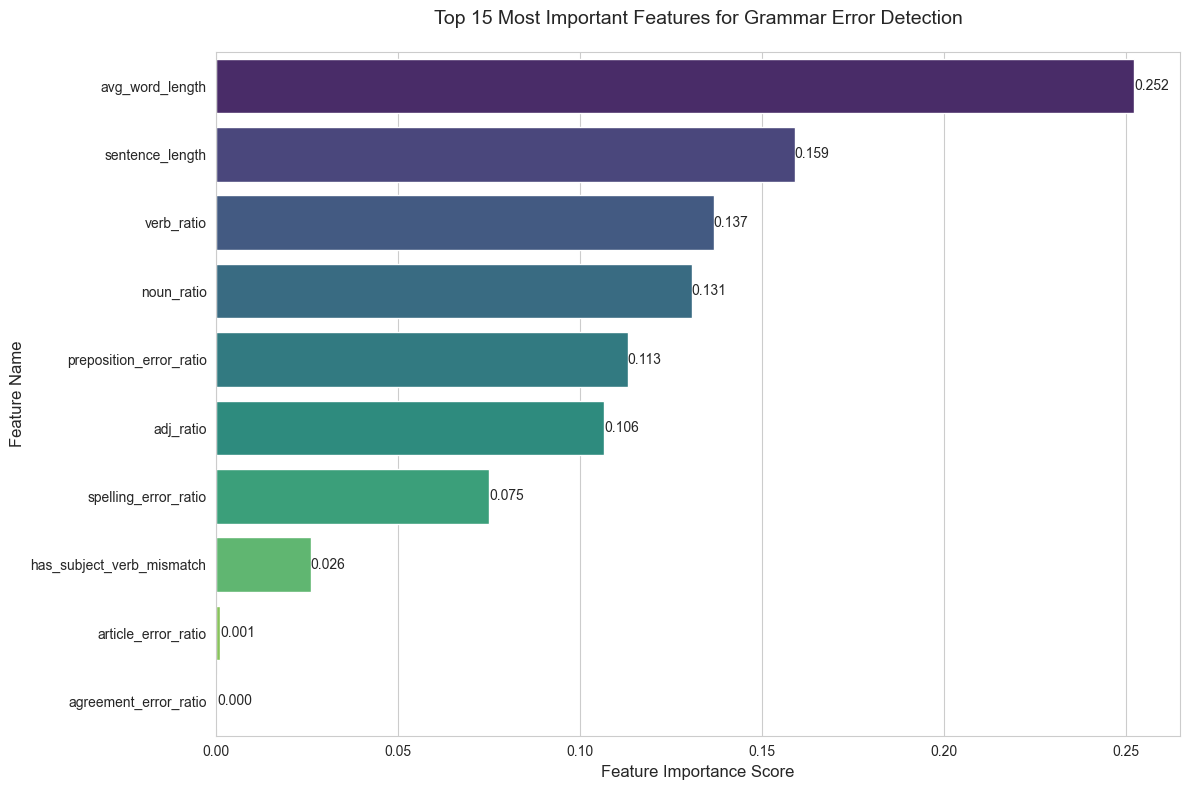


Detailed Feature Importance:
avg_word_length                0.2521
sentence_length                0.1589
verb_ratio                     0.1367
noun_ratio                     0.1306
preposition_error_ratio        0.1130
adj_ratio                      0.1065
spelling_error_ratio           0.0750
has_subject_verb_mismatch      0.0259
article_error_ratio            0.0010
agreement_error_ratio          0.0002


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance():
    # Lấy feature names và importance scores từ RandomForest
    feature_names = vectorizer.get_feature_names_out()
    importances = model.named_steps['classifier'].feature_importances_
    
    # Tạo DataFrame chứa features và importance scores
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    
    # Sắp xếp theo importance giảm dần và lấy top 15 features
    feature_importance = feature_importance.sort_values('importance', ascending=False).head(15)
    
    # Set style và tạo figure 
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 8))
    
    # Vẽ barplot với seaborn
    ax = sns.barplot(data=feature_importance, 
                    y='feature', 
                    x='importance',
                    palette='viridis')
    
    # Thêm title và labels
    plt.title('Top 15 Most Important Features for Grammar Error Detection', 
             fontsize=14, pad=20)
    plt.xlabel('Feature Importance Score', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    
    # Thêm giá trị lên mỗi bar
    for i, v in enumerate(feature_importance['importance']):
        ax.text(v, i, f'{v:.3f}', va='center', fontsize=10)
    
    # Chỉnh margins
    plt.tight_layout()
    
    # Save plot
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Hiển thị thông tin chi tiết
    print("\nDetailed Feature Importance:")
    print("=" * 50)
    for idx, row in feature_importance.iterrows():
        print(f"{row['feature']:<30} {row['importance']:.4f}")

# Vẽ biểu đồ
plot_feature_importance()